##**Predicting BACE-1 Inhibitor Activity**

###Exercise 0: Setup

In [1]:
!pip install pandas numpy scikit-learn matplotlib rdkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 54.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

In [4]:
df = pd.read_csv("bace.csv")
df.head()
df.shape
df.columns.tolist()[:20]
df[['mol', 'Class']].head()

,mol,Class
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,1
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,1
2,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,1
3,S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...,1
4,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,1


In [5]:
# Which column contains the SMILES strings?
print("SMILES column:", 'mol')

# Which column contains the binary activity label?
print("Binary label column:", 'Class')

# Are there any missing values?
print(df[['mol', 'Class']].isna().sum())

# Missing values across the whole dataset
print("Rows with any missing values:", df.isna().any(axis=1).sum())

# Is the label distribution balanced or imbalanced?
print(df['Class'].value_counts())

SMILES column: mol
Binary label column: Class
mol      0
Class    0
dtype: int64
Rows with any missing values: 0
Class
0    822
1    691
Name: count, dtype: int64


Note: The dataset is fairly balanced, though not perfectly.

In [6]:
df['target'] = df['Class'].astype(int)

df[['mol', 'Class', 'target']].head()

,mol,Class,target
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,1,1
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,1,1
2,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,1,1
3,S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...,1,1
4,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,1,1


**Markdown explanation:**


*   The prediction target in this project is whether a molecule is active or inactive against BACE-1, represented by the binary ```Class``` column. Biologically, this means we are asking whether a compound shows inhibitory activity toward the BACE-1 target rather than trying to predict a continous potency value directly.
*   Binary classification is reasonable here because it matches a practical early-screening question in drug discovery: should this molecule be considered a likely hit or not? It also makes the modeling setup simpler and allows straightforward comparison between baseline and more advanced classifiers.
*   Reducing activity to a binary label loses information. Molecules with very different potency values may end up in the same class, and the exact cutoff used to define "active" versus "inactive" can affect interpretation. So while binary labels are useful for a first-pass screen, they do not capture the full biological nuance of inhibition strength.



###Exercise 1: Explore the Dataset

In [7]:
df.head()

,mol,CID,Class,Model,pIC50,MW,AlogP,HBA,HBD,RB,...,PEOE7 (PEOE7),PEOE8 (PEOE8),PEOE9 (PEOE9),PEOE10 (PEOE10),PEOE11 (PEOE11),PEOE12 (PEOE12),PEOE13 (PEOE13),PEOE14 (PEOE14),canvasUID,target
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,BACE_1,1,Train,9.154901,431.56979,4.4014,3,2,5,...,78.640335,226.85541,107.43491,37.133846,0.000000,7.980170,0.0,0.000000,1,1
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,BACE_2,1,Train,8.853872,657.81073,2.6412,5,4,16,...,47.171600,365.67694,174.07675,34.923889,7.980170,24.148668,0.0,24.663788,2,1
2,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,BACE_3,1,Train,8.698970,591.74091,2.5499,4,3,11,...,47.941147,192.40652,255.75255,23.654478,0.230159,15.879790,0.0,24.663788,3,1
3,S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...,BACE_4,1,Train,8.698970,591.67828,3.1680,4,3,12,...,37.954151,194.35304,202.76335,36.498634,0.980913,8.188327,0.0,26.385181,4,1
4,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,BACE_5,1,Train,8.698970,629.71283,3.5086,3,3,11,...,39.361153,179.71288,220.46130,23.654478,0.230159,15.879790,0.0,26.100143,5,1


In [8]:
n_molecules = len(df)
class_counts = df['target'].value_counts().sort_index()
missing_values = df.isna().sum().sum()
duplicate_smiles = df['mol'].duplicated().sum()

print("Number of molecules:", n_molecules)
print("\nClass counts:")
print(class_counts)
print("\nTotal missing values in dataset:", missing_values)
print("Duplicate SMILES:", duplicate_smiles)

Number of molecules: 1513

Class counts:
target
0    822
1    691
Name: count, dtype: int64

Total missing values in dataset: 0
Duplicate SMILES: 0


In [9]:
df['Mol'] = df['mol'].apply(Chem.MolFromSmiles)
failed = df['Mol'].isna().sum()
print("Failed SMILES parses:", failed)

df[['mol', 'Mol']].head()

Failed SMILES parses: 0


,mol,Mol
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,<rdkit.Chem.rdchem.Mol object at 0x7cf52a71da10>
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,<rdkit.Chem.rdchem.Mol object at 0x7cf529352ea0>
2,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,<rdkit.Chem.rdchem.Mol object at 0x7cf529353a00>
3,S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...,<rdkit.Chem.rdchem.Mol object at 0x7cf529352ce0>
4,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,<rdkit.Chem.rdchem.Mol object at 0x7cf529352f10>


Note: I converted the SMILES strings in the ```mol``` column into RDKit molecule objects using ```Chem.MolFromSmiles```. In this dataset, all molecules parsed successfully, so no rows needed to be removed for invalid SMILES.

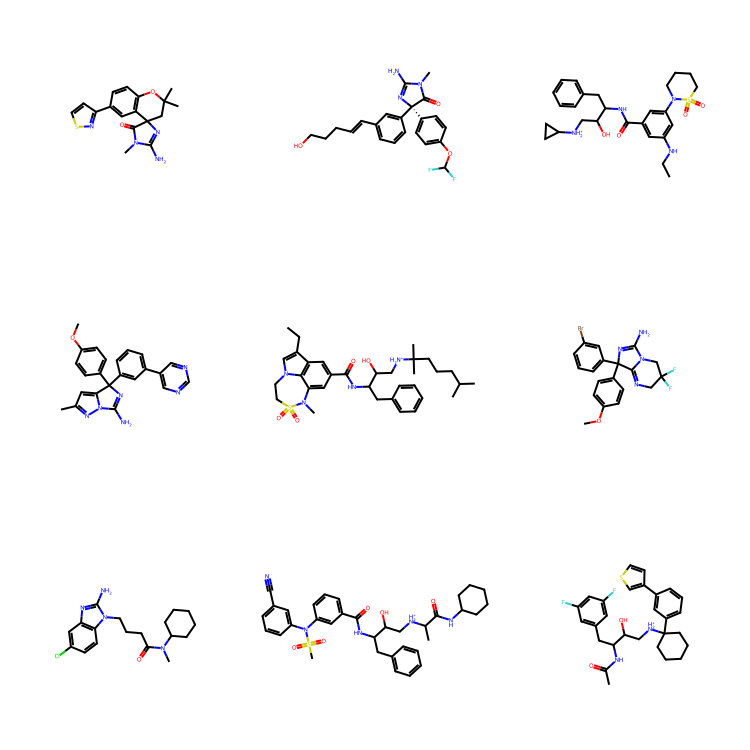

In [10]:
sample_df = df.sample(9, random_state=42)
sample_mols = sample_df['Mol'].tolist()

Draw.MolsToGridImage(
    sample_mols,
    molsPerRow=3,
    subImgSize=(250, 250)
)

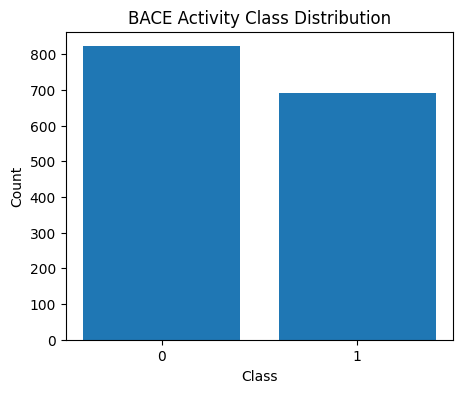

target
0    0.543291
1    0.456709
Name: proportion, dtype: float64


In [11]:
class_counts = df['target'].value_counts().sort_index()

plt.figure(figsize=(5,4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("BACE Activity Class Distribution")
plt.show()

class_props = df['target'].value_counts(normalize=True).sort_index()
print(class_props)

**Markdown explanation:**


*   The class imbalance in this dataset is mild. There are 822 inactive molecules and 691 active molecules, so the classes are reasonably close in size.
*   This is much better than a heavily skewed dataset, but the imbalance is still worth paying attention to evaluation metrics beyond simple accuracy (ROC-AUC, PR-AUC, F1, confusion matrix).
*   If the positive class were rarer, metrics such as PR-AUC and F1 score would become especially important, because ROC-AUC can still look strong even when the model struggles on the minority class. The confusion matrix is also useful because it shows whether the model is missing many actives or producing too many false positives. In general, when positive hits are the more important class in drug discovery, PR-AUC, F1, and the confusion matrix are often more informative than accuracy alone.

###Exercise 2: Generate Molecular Features

In [12]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def mol_to_fp_array(mol):
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((1024,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

X_fp = np.vstack(df['Mol'].apply(mol_to_fp_array).values)
X_fp.shape

(1513, 1024)

In [13]:
from rdkit.Chem import Descriptors

df['MolWt'] = df['Mol'].apply(Descriptors.MolWt)
df['MolLogP'] = df['Mol'].apply(Descriptors.MolLogP)
df['TPSA'] = df['Mol'].apply(Descriptors.TPSA)
df['NumHDonors'] = df['Mol'].apply(Descriptors.NumHDonors)
df['NumHAcceptors'] = df['Mol'].apply(Descriptors.NumHAcceptors)

descriptor_cols = ['MolWt', 'MolLogP', 'TPSA', 'NumHDonors', 'NumHAcceptors']
X_desc = df[descriptor_cols].values

X_desc.shape

(1513, 5)

In [14]:
y = df['target'].values

print("Fingerprint matrix shape:", X_fp.shape)
print("Descriptor matrix shape:", X_desc.shape)
print("Label vector shape:", y.shape)

Fingerprint matrix shape: (1513, 1024)
Descriptor matrix shape: (1513, 5)
Label vector shape: (1513,)


**Markdown explanation:**


*   Morgan fingerprints and molecular descriptors represent different kinds of chemical information. Fingerprints capture local substructure patterns: effectively whether certain molecular fragments, neighborhoods, or connectivity motifs are present in a molecule. In contrast, descriptors summarize broader physicochemical properties such as size, polarity, and lipophilicity.
*   Fingerprints may be a better primary representation for target activity prediction because binding to a protein target often depends on specific structural motifs rather than only overall bulk properties. A model built on fingerprints can potentially distinguish molecules that have similar molecular weight or logP but differ in key substructures relevant to activity.
*   Descriptors still provide value because they are much more interpretable: it is easier to explain a pattern in terms of molecular weight, polarity, or hydrogen-bonding capacity than in terms of hundreds of fingerprint bits. The tradeoff is that descriptors compress the molecule into a few summary values, so they may miss structural details that matter for target recognition.

###Exercise 3: Build a Baseline Model

In [15]:
from sklearn.model_selection import train_test_split

X_train_fp, X_test_fp, y_train, y_test = train_test_split(
    X_fp, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train_fp.shape)
print("Test set shape:", X_test_fp.shape)

Training set shape: (1210, 1024)
Test set shape: (303, 1024)


In [16]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=2000,
    solver='liblinear',
    random_state=42
)

logreg.fit(X_train_fp, y_train)

LogisticRegression(max_iter=2000, random_state=42, solver='liblinear')

In [17]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    confusion_matrix
)

y_prob_lr = logreg.predict_proba(X_test_fp)[:, 1]
y_pred_lr = logreg.predict(X_test_fp)

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
pr_auc_lr = average_precision_score(y_test, y_prob_lr)
f1_lr = f1_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Logistic Regression Results")
print("ROC-AUC:", roc_auc_lr)
print("PR-AUC:", pr_auc_lr)
print("F1 score:", f1_lr)
print("Confusion matrix:\n", cm_lr)

Logistic Regression Results
ROC-AUC: 0.8731884057971014
PR-AUC: 0.8422116363447374
F1 score: 0.7553956834532374
Confusion matrix:
 [[130  35]
 [ 33 105]]


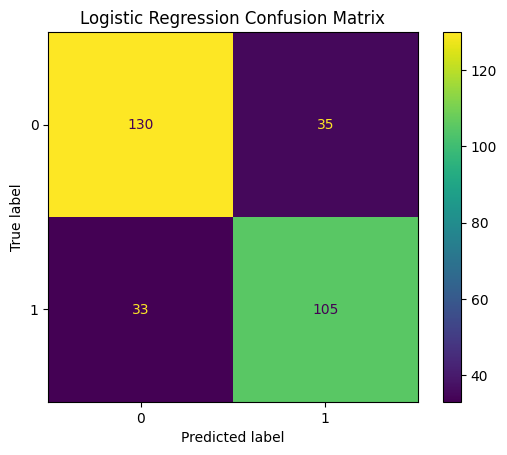

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

**Markdown explanation:**


*   The logistic regression baseline performs fairly well, with a ROC-AUC of about 0.87 and a PR-AUC of about 0.84 on a random split. That is a strong enough result to suggest that Morgan fingerprints contain useful information for distinguishing active and inactive BACE-1 compounds, even with a relatively simple linear model.
*   Random-split performance can make this task look easier than it really is because in molecular datasets, structurally similar compounds often appear in both the training and test sets, so the model may partially benefit from seeing related chemotypes during training rather than truly generalizing to new chemical scaffolds.
*   To make a stronger claim, we would need to test performance under a stricter split strategy such as a scaffold-based split, where related core structures are kept apart between train and test.

###Exercise 4: Train a Stronger Comparison Model

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_fp, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [20]:
y_prob_rf = rf.predict_proba(X_test_fp)[:, 1]
y_pred_rf = rf.predict(X_test_fp)

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)
f1_rf = f1_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Results")
print("ROC-AUC:", roc_auc_rf)
print("PR-AUC:", pr_auc_rf)
print("F1 score:", f1_rf)
print("Confusion matrix:\n", cm_rf)

Random Forest Results
ROC-AUC: 0.8824549846288976
PR-AUC: 0.8603991177710487
F1 score: 0.7753623188405797
Confusion matrix:
 [[134  31]
 [ 31 107]]


In [21]:
results_df = pd.DataFrame([
    {
        'model': 'Logistic Regression',
        'split type': 'Random (stratified)',
        'ROC-AUC': roc_auc_lr,
        'PR-AUC': pr_auc_lr,
        'F1 score': f1_lr
    },
    {
        'model': 'Random Forest',
        'split type': 'Random (stratified)',
        'ROC-AUC': roc_auc_rf,
        'PR-AUC': pr_auc_rf,
        'F1 score': f1_rf
    }
])

results_df.round(3)

,model,split type,ROC-AUC,PR-AUC,F1 score
0,Logistic Regression,Random (stratified),0.873,0.842,0.755
1,Random Forest,Random (stratified),0.882,0.860,0.775


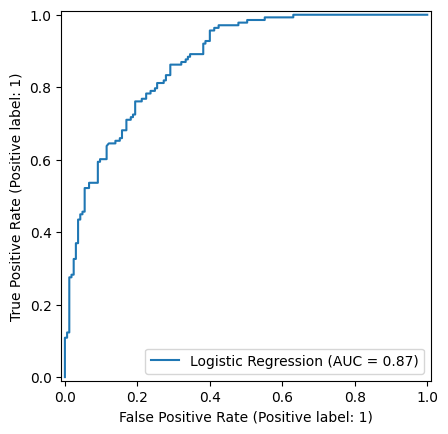

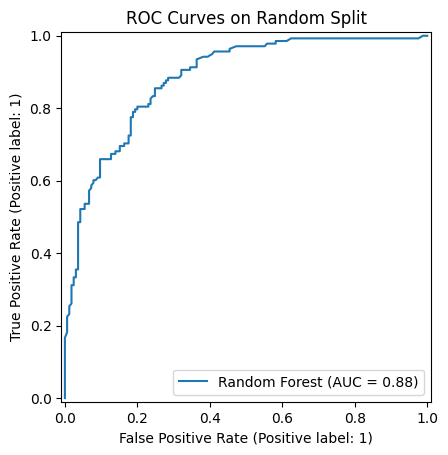

In [22]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest")
plt.title("ROC Curves on Random Split")
plt.show()

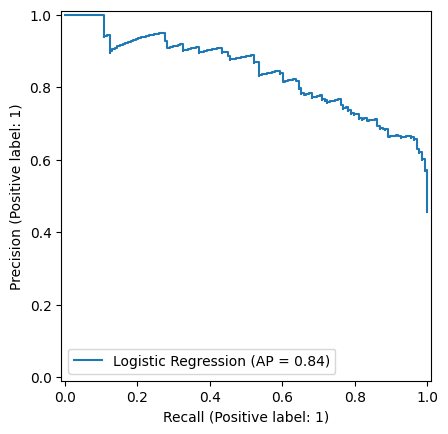

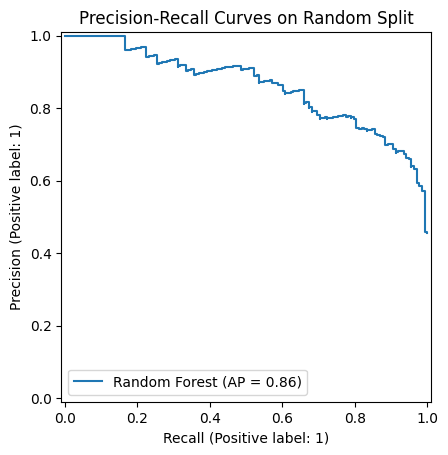

In [23]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_prob_lr, name="Logistic Regression")
PrecisionRecallDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest")
plt.title("Precision-Recall Curves on Random Split")
plt.show()

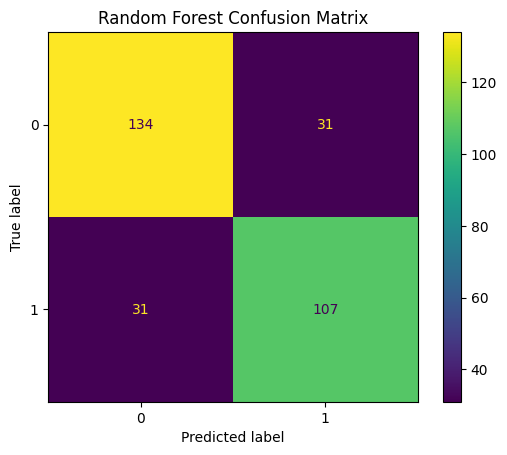

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

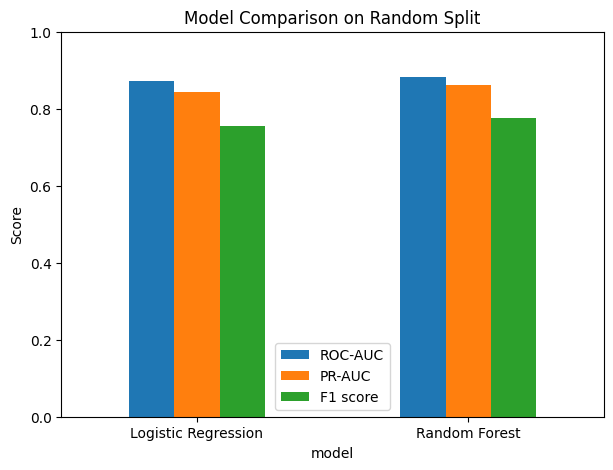

In [25]:
plot_df = results_df.set_index('model')[['ROC-AUC', 'PR-AUC', 'F1 score']]

plot_df.plot(kind='bar', figsize=(7,5))
plt.title("Model Comparison on Random Split")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.show()

**Markdown explanation:**


*   On the random split, Random Forest slightly outperforms Logistic Regression across all three main metrics. ROC-AUC improves from about 0.873 to 0.882, PR-AUC from about 0.842 to 0.860, and F1 from about 0.755 to 0.775.
*   The nonlinear model does better, but the improvement is relatively modest rather than dramatic.
*   A stronger nonlinear model does not automatically mean a more useful scientific model, especially if the gain is small and the interpretation becomes harder. Logistic regression is simpler and easier to reason about, while Random Forest may capture more complex feature interactions.
*   If both models perform well on a random split, there is still a major uncertainty: are they learning patterns that generalize to genuinely new chemistry, or are they benefiting from scaffold overlap between train and test? That is why the scaffold-based split is the real crux of the project and the next result that matters most.

###Exercise 5: The Crux – Test Generalization with a Scaffold Split

In [26]:
from rdkit.Chem.Scaffolds import MurckoScaffold

def murcko_scaffold_smiles(mol):
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

df['scaffold'] = df['Mol'].apply(murcko_scaffold_smiles)

df[['mol', 'scaffold']].head()

,mol,scaffold
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,O=C(CCc1cnc2ccc(-c3ccccc3)cc2c1)NC1CCOCC1
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,O=C(NC(Cc1ccccc1)CC1CCC[NH2+]1)C(CCc1ccccc1)N1...
2,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,O=C(NC(CC[NH2+]Cc1ccccc1)Cc1ccccc1)c1cc2c3c(cc...
3,S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...,O=S1(=O)CC(Cc2ccccc2)CC([NH2+]Cc2ccccc2)C1
4,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,O=C(NC(CC[NH2+]Cc1ccccc1)Cc1ccccc1)c1cc2c3c(cc...


In [27]:
print("Number of unique scaffolds:", df['scaffold'].nunique())

Number of unique scaffolds: 671


In [29]:
from collections import defaultdict

scaffold_to_indices = defaultdict(list)
for idx, scaf in enumerate(df['scaffold']):
    scaffold_to_indices[scaf].append(idx)

# Sort scaffold groups from largest to smallest for a deterministic split
scaffold_groups = sorted(
    scaffold_to_indices.values(),
    key=lambda inds: (-len(inds), inds[0])
)

n_total = len(df)
target_test_size = int(round(0.2 * n_total))

train_indices = []
test_indices = []
current_test_size = 0

for group in scaffold_groups:
    if current_test_size < target_test_size:
        test_indices.extend(group)
        current_test_size += len(group)
    else:
        train_indices.extend(group)

print("Train size:", len(train_indices))
print("Test size:", len(test_indices))
print("Overlap:", len(set(train_indices) & set(test_indices)))

Train size: 1207
Test size: 306
Overlap: 0


In [30]:
y_train_scaf = y[train_indices]
y_test_scaf = y[test_indices]

print("Train class counts:", np.bincount(y_train_scaf))
print("Test class counts:", np.bincount(y_test_scaf))
print("Train positive rate:", y_train_scaf.mean())
print("Test positive rate:", y_test_scaf.mean())

Train class counts: [701 506]
Test class counts: [121 185]
Train positive rate: 0.41922120961060483
Test positive rate: 0.6045751633986928


In [31]:
X_train_scaf = X_fp[train_indices]
X_test_scaf = X_fp[test_indices]

# Logistic Regression
logreg_scaf = LogisticRegression(
    max_iter=2000,
    solver='liblinear',
    random_state=42
)
logreg_scaf.fit(X_train_scaf, y_train_scaf)

# Random Forest
rf_scaf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_scaf.fit(X_train_scaf, y_train_scaf)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [32]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    confusion_matrix
)

# Logistic Regression predictions
y_prob_lr_scaf = logreg_scaf.predict_proba(X_test_scaf)[:, 1]
y_pred_lr_scaf = logreg_scaf.predict(X_test_scaf)

# Random Forest predictions
y_prob_rf_scaf = rf_scaf.predict_proba(X_test_scaf)[:, 1]
y_pred_rf_scaf = rf_scaf.predict(X_test_scaf)

# Metrics
roc_auc_lr_scaf = roc_auc_score(y_test_scaf, y_prob_lr_scaf)
pr_auc_lr_scaf = average_precision_score(y_test_scaf, y_prob_lr_scaf)
f1_lr_scaf = f1_score(y_test_scaf, y_pred_lr_scaf)
cm_lr_scaf = confusion_matrix(y_test_scaf, y_pred_lr_scaf)

roc_auc_rf_scaf = roc_auc_score(y_test_scaf, y_prob_rf_scaf)
pr_auc_rf_scaf = average_precision_score(y_test_scaf, y_prob_rf_scaf)
f1_rf_scaf = f1_score(y_test_scaf, y_pred_rf_scaf)
cm_rf_scaf = confusion_matrix(y_test_scaf, y_pred_rf_scaf)

print("Scaffold Split — Logistic Regression")
print("ROC-AUC:", roc_auc_lr_scaf)
print("PR-AUC:", pr_auc_lr_scaf)
print("F1 score:", f1_lr_scaf)
print("Confusion matrix:\n", cm_lr_scaf)

print("\nScaffold Split — Random Forest")
print("ROC-AUC:", roc_auc_rf_scaf)
print("PR-AUC:", pr_auc_rf_scaf)
print("F1 score:", f1_rf_scaf)
print("Confusion matrix:\n", cm_rf_scaf)

Scaffold Split — Logistic Regression
ROC-AUC: 0.8278088005360733
PR-AUC: 0.8714680454716459
F1 score: 0.8
Confusion matrix:
 [[ 87  34]
 [ 39 146]]

Scaffold Split — Random Forest
ROC-AUC: 0.8285012285012286
PR-AUC: 0.8746290939635439
F1 score: 0.8136482939632546
Confusion matrix:
 [[ 80  41]
 [ 30 155]]


In [33]:
scaffold_results_df = pd.DataFrame([
    {
        'model': 'Logistic Regression',
        'split type': 'Random',
        'ROC-AUC': roc_auc_lr,
        'PR-AUC': pr_auc_lr,
        'F1 score': f1_lr
    },
    {
        'model': 'Random Forest',
        'split type': 'Random',
        'ROC-AUC': roc_auc_rf,
        'PR-AUC': pr_auc_rf,
        'F1 score': f1_rf
    },
    {
        'model': 'Logistic Regression',
        'split type': 'Scaffold',
        'ROC-AUC': roc_auc_lr_scaf,
        'PR-AUC': pr_auc_lr_scaf,
        'F1 score': f1_lr_scaf
    },
    {
        'model': 'Random Forest',
        'split type': 'Scaffold',
        'ROC-AUC': roc_auc_rf_scaf,
        'PR-AUC': pr_auc_rf_scaf,
        'F1 score': f1_rf_scaf
    }
])

scaffold_results_df.round(3)

,model,split type,ROC-AUC,PR-AUC,F1 score
0,Logistic Regression,Random,0.873,0.842,0.755
1,Random Forest,Random,0.882,0.860,0.775
2,Logistic Regression,Scaffold,0.828,0.871,0.800
3,Random Forest,Scaffold,0.829,0.875,0.814


In [34]:
print("Logistic Regression ROC-AUC drop:",
      round(roc_auc_lr - roc_auc_lr_scaf, 3))
print("Random Forest ROC-AUC drop:",
      round(roc_auc_rf - roc_auc_rf_scaf, 3))

Logistic Regression ROC-AUC drop: 0.045
Random Forest ROC-AUC drop: 0.054


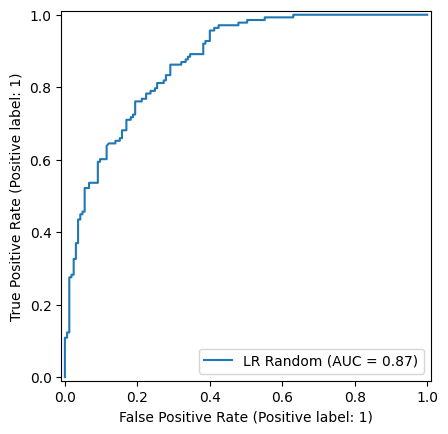

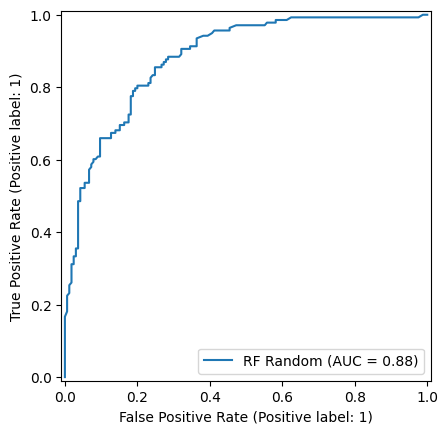

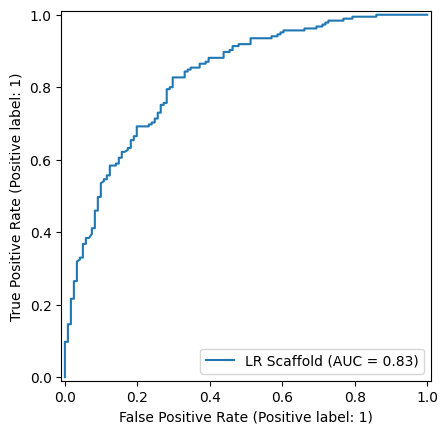

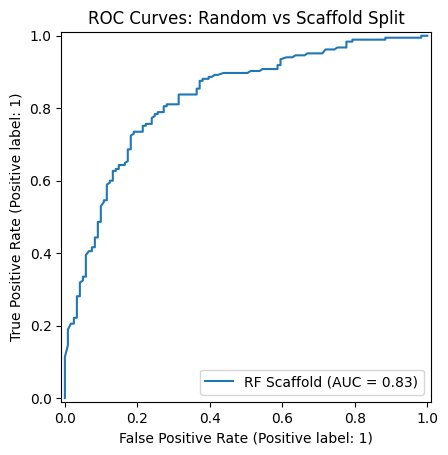

In [35]:
from sklearn.metrics import RocCurveDisplay

# Random split
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="LR Random")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="RF Random")

# Scaffold split
RocCurveDisplay.from_predictions(y_test_scaf, y_prob_lr_scaf, name="LR Scaffold")
RocCurveDisplay.from_predictions(y_test_scaf, y_prob_rf_scaf, name="RF Scaffold")

plt.title("ROC Curves: Random vs Scaffold Split")
plt.show()

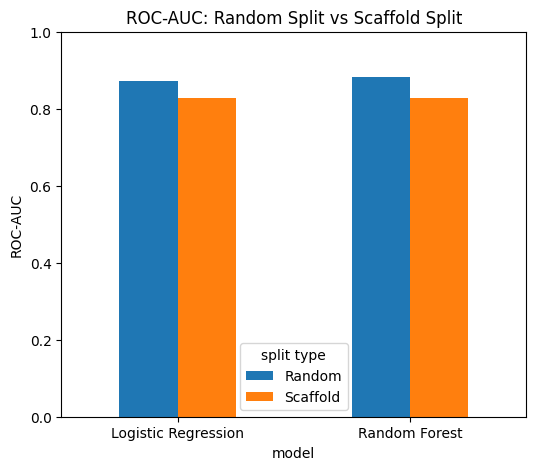

In [36]:
pivot_df = scaffold_results_df.pivot(index='model', columns='split type', values='ROC-AUC')
pivot_df.plot(kind='bar', figsize=(6,5))
plt.title("ROC-AUC: Random Split vs Scaffold Split")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

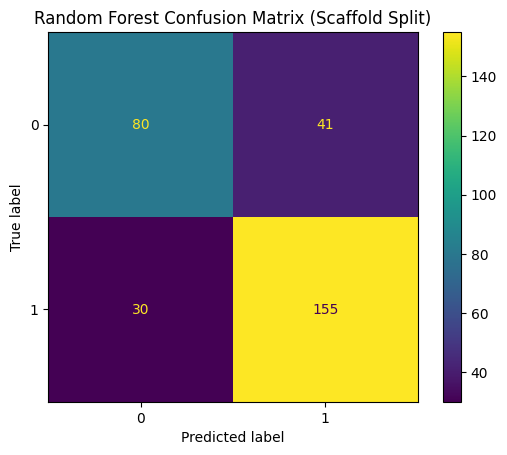

In [37]:
ConfusionMatrixDisplay.from_predictions(y_test_scaf, y_pred_rf_scaf)
plt.title("Random Forest Confusion Matrix (Scaffold Split)")
plt.show()

**Markdown explanation:**


*   Yes, performance does drop under the scaffold split when we look at ROC-AUC, which is the clearest sign that random-split performance was somewhat optimistic.
*   Logistic Regression drops from about 0.873 to 0.828, while Random Forest drops from about 0.882 to 0.829. That means the stricter scaffold-based evaluation reduces ROC-AUC by about 0.045–0.054, which is a meaningful loss in ranking performance.
*   Under the stricter split, the stronger nonlinear model no longer shows a meaningful advantage: Random Forest and Logistic Regression end up with almost identical ROC-AUC. This suggests that some of the apparent gain from the nonlinear model on the random split may have reflected familiarity with scaffold-related structure patterns rather than a true generalization advantage.
*   The gap between random-split and scaffold-split ROC-AUC suggests that part of the original performance was likely inflated by scaffold overlap between train and test. In other words, the model is learning something real, but the random split makes the task look easier because similar chemotypes appear on both sides of the split. For real drug discovery, the scaffold split is the result we should trust more, because it better reflects the challenge of making predictions on structurally novel compounds.
*   One subtlety is that PR-AUC and F1 did not decrease here, and in fact increased slightly. That does not mean scaffold generalization is easier. In this particular split, the scaffold-based test set has a higher fraction of active molecules than the random-split test set, which can make PR-AUC and F1 look better. That is why ROC-AUC is the most reliable main metric for comparing the two split strategies in this analysis.

###Exercise 6: Reflect on the Result

1. Scaffold split is more informative because molecules that share a core scaffold are often chemically very similar, even if they differ in substituents. In a random split, those related compounds can appear in both training and test sets, allowing the model to benefit from memorizing familiar chemotypes rather than learning broader rules that transfer to new chemistry. By separating molecules at the scaffold level, scaffold split provides a stricter and more realistic test of whether the model can generalize to structurally novel compounds.
2. The drop in ROC-AUC from the random split to the scaffold split suggests that part of the original performance was inflated by structural overlap between training and test molecules. This means the benchmark is not just measuring “can the model predict activity,” but also “how much does the split let the model see familiar chemistry ahead of time.” The gap therefore acts as evidence that random-split results can overestimate real-world generalization, and that scaffold-aware evaluation is necessary to tell memorization apart from transferable chemical learning.
3. On the random split, Random Forest performed slightly better than Logistic Regression, but the improvement was modest rather than dramatic. On the scaffold split, that advantage essentially disappeared, with both models landing at nearly the same ROC-AUC. This suggests that while the nonlinear model may capture some extra structure under easier conditions, it did not provide a strong generalization advantage once the evaluation became more chemically realistic.
4. In the full dataset, class imbalance was only mild, so accuracy and ROC-AUC were still useful. However, ROC-AUC alone was not enough, because PR-AUC, F1 score, and the confusion matrix helped show how the models handled the positive class in more detail. In the scaffold split, the class balance shifted noticeably, which made PR-AUC and F1 harder to compare directly across split strategies. That reinforced the importance of looking at multiple metrics and interpreting them in the context of the actual class distribution.
5. This project has several limitations. First, the labels are binary, so they compress biological activity into a yes/no outcome and lose information about potency magnitude. Second, even though the dataset is useful and well-curated, its size is still limited relative to the vast chemical space relevant to drug discovery. Third, label noise and assay variability may affect performance in ways the model cannot distinguish. Finally, even a scaffold split is still only a benchmark evaluation: it is more realistic than a random split, but it is not the same as testing the model prospectively on truly new compounds from a future discovery campaign.